In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [ ]:
ruta = "https://raw.githubusercontent.com/jamc88/Taller-Modelado-I/refs/heads/main/Bases_datos_proyecto_integrador/contaminantes_CDMX_2021-2023.csv"
df = pd.read_csv(ruta)
df


,fecha,CO,NO,NO2,NOX,O3,PM10,PM25,SO2
0,2021-01-01,0.417782,5.712963,16.977273,23.261574,29.765494,54.327273,28.594855,1.125912
1,2021-01-02,0.515087,14.289894,26.782609,42.090426,33.647969,48.196481,23.465409,1.725000
2,2021-01-03,0.446905,12.328571,22.773256,35.714286,28.135823,39.091988,16.423676,1.548983
3,2021-01-04,0.580398,22.323040,31.306483,54.418052,28.824532,52.486239,23.160000,3.410019
4,2021-01-05,0.533105,19.386091,29.376218,49.995204,28.941374,55.916667,22.694444,5.251366
...,...,...,...,...,...,...,...,...,...
876,2023-05-27,0.256722,3.750583,17.284351,21.629371,41.580645,36.774011,21.170139,2.735683
877,2023-05-28,0.286826,3.458886,16.349241,20.230769,36.913761,28.580000,18.454861,2.331658
878,2023-05-29,0.482077,11.448113,24.521154,36.436321,29.697068,30.241486,16.692857,1.071588
879,2023-05-30,0.441455,13.893519,22.615530,37.224537,36.185971,35.859532,20.888525,1.181818


In [ ]:

df["fecha"] = pd.to_datetime(df["fecha"])

df["casos_diario_PM2.5"] = df.iloc[:, 7]

df = df[["fecha", "casos_diario_PM2.5"]].copy()

df = df.rename(columns={'fecha': 'dia'})

print("Nuevo tamaño del DataFrame:", df.shape)
print(df.head())

Nuevo tamaño del DataFrame: (881, 2)
         dia  casos_diario_PM2.5
0 2021-01-01           28.594855
1 2021-01-02           23.465409
2 2021-01-03           16.423676
3 2021-01-04           23.160000
4 2021-01-05           22.694444


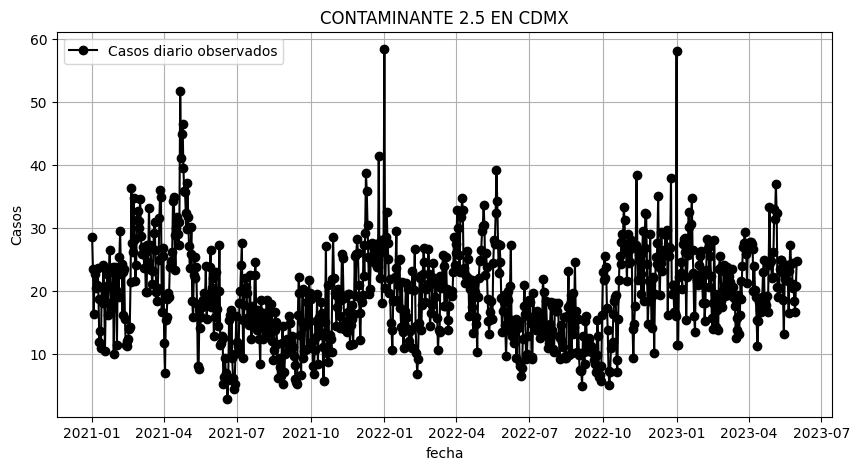

In [ ]:
plt.figure(figsize=(10, 5))

plt.plot(
    df["dia"],
    df["casos_diario_PM2.5"],
    marker="o",
    label="Casos diario observados",
    color='black'
)

plt.xlabel("fecha")
plt.ylabel("Casos")
plt.title("CONTAMINANTE 2.5 EN CDMX")
plt.xticks()
plt.legend()
plt.grid()

plt.show()

In [ ]:

df["lag_1"] = df["casos_diario_PM2.5"].shift(1) # Rezagos
df["lag_2"] = df["casos_diario_PM2.5"].shift(2)
df["lag_3"] = df["casos_diario_PM2.5"].shift(3)

df["promedio_movil_3"] = df["casos_diario_PM2.5"].rolling(window=3).mean() # Promedios móviles
df["promedio_movil_5"] = df["casos_diario_PM2.5"].rolling(window=5).mean()

df["cambio_diario"] = df["casos_diario_PM2.5"].diff() # Cambio semanal

df["casos_siguiente_dia"] = df["casos_diario_PM2.5"].shift(-1) # Variable objetivo

df["cambio_relativo"] = (
    df["casos_diario_PM2.5"] - df["lag_1"]
) / df["lag_1"]

df["cambio_relativo"] = df["cambio_relativo"].replace(
    [np.inf, -np.inf],
    np.nan
)


In [ ]:
df["casos_siguiente_dia"] = df["casos_diario_PM2.5"].shift(-1)

df.head(10)

,dia,casos_diario_PM2.5,lag_1,lag_2,lag_3,promedio_movil_3,promedio_movil_5,cambio_diario,casos_siguiente_dia,cambio_relativo
0,2021-01-01,28.594855,NaN,NaN,NaN,NaN,NaN,NaN,23.465409,NaN
1,2021-01-02,23.465409,28.594855,NaN,NaN,NaN,NaN,-5.129447,16.423676,-0.179384
2,2021-01-03,16.423676,23.465409,28.594855,NaN,22.827980,NaN,-7.041733,23.160000,-0.300090
3,2021-01-04,23.160000,16.423676,23.465409,28.594855,21.016362,NaN,6.736324,22.694444,0.410159
4,2021-01-05,22.694444,23.160000,16.423676,23.465409,20.759373,22.867677,-0.465556,20.473214,-0.020102
5,2021-01-06,20.473214,22.694444,23.160000,16.423676,22.109220,21.243349,-2.221230,21.035821,-0.097876
6,2021-01-07,21.035821,20.473214,22.694444,23.160000,21.401160,20.757431,0.562607,23.665653,0.027480
7,2021-01-08,23.665653,21.035821,20.473214,22.694444,21.724896,22.205827,2.629833,18.708333,0.125017
8,2021-01-09,18.708333,23.665653,21.035821,20.473214,21.136603,21.315493,-4.957320,11.921922,-0.209473
9,2021-01-10,11.921922,18.708333,23.665653,21.035821,18.098636,19.160989,-6.786411,13.735099,-0.362748


In [ ]:
df["riesgo_siguiente_dia"], cortes = pd.qcut(
    df["casos_siguiente_dia"],
    q=3,
    labels=["bajo", "medio", "alto"],
    retbins=True
)

In [ ]:
df_cortes = pd.DataFrame({
    "categoria": ["bajo", "medio", "alto"],
    "desde": [cortes[0], cortes[1], cortes[2]],
    "hasta": [cortes[1], cortes[2], cortes[3]]
})

df_cortes

,categoria,desde,hasta
0,bajo,2.849315,16.003115
1,medio,16.003115,22.605769
2,alto,22.605769,58.414835


In [ ]:
df[["dia", "casos_diario_PM2.5", "casos_siguiente_dia", "riesgo_siguiente_dia"]].head(10)

,dia,casos_diario_PM2.5,casos_siguiente_dia,riesgo_siguiente_dia
0,2021-01-01,28.594855,23.465409,alto
1,2021-01-02,23.465409,16.423676,medio
2,2021-01-03,16.423676,23.160000,alto
3,2021-01-04,23.160000,22.694444,alto
4,2021-01-05,22.694444,20.473214,medio
5,2021-01-06,20.473214,21.035821,medio
6,2021-01-07,21.035821,23.665653,alto
7,2021-01-08,23.665653,18.708333,medio
8,2021-01-09,18.708333,11.921922,bajo
9,2021-01-10,11.921922,13.735099,bajo


In [ ]:
df["riesgo_siguiente_dia"].value_counts()

,count
riesgo_siguiente_dia,
bajo,294
medio,293
alto,293


In [ ]:
columnas_modelo = [
    "dia",
    "casos_diario_PM2.5",
    "lag_1",
    "lag_2",
    "lag_3",
    "promedio_movil_3",
    "promedio_movil_5",
    "cambio_diario",
    "cambio_relativo",
    "casos_siguiente_dia",
    "riesgo_siguiente_dia"
]

df_modelo = df[columnas_modelo].dropna().reset_index(drop=True)

df_modelo.head()

,dia,casos_diario_PM2.5,lag_1,lag_2,lag_3,promedio_movil_3,promedio_movil_5,cambio_diario,cambio_relativo,casos_siguiente_dia,riesgo_siguiente_dia
0,2021-01-05,22.694444,23.160000,16.423676,23.465409,20.759373,22.867677,-0.465556,-0.020102,20.473214,medio
1,2021-01-06,20.473214,22.694444,23.160000,16.423676,22.109220,21.243349,-2.221230,-0.097876,21.035821,medio
2,2021-01-07,21.035821,20.473214,22.694444,23.160000,21.401160,20.757431,0.562607,0.027480,23.665653,alto
3,2021-01-08,23.665653,21.035821,20.473214,22.694444,21.724896,22.205827,2.629833,0.125017,18.708333,medio
4,2021-01-09,18.708333,23.665653,21.035821,20.473214,21.136603,21.315493,-4.957320,-0.209473,11.921922,bajo


In [ ]:
variables_predictoras = [
    "casos_diario_PM2.5",
    "lag_1",
    "lag_2",
    "lag_3",
    "promedio_movil_3",
    "promedio_movil_5",
    "cambio_diario",
    "cambio_relativo"
]

X = df_modelo[variables_predictoras]

y = df_modelo["riesgo_siguiente_dia"]

print(X.head())
print(y.head())


   casos_diario_PM2.5      lag_1      lag_2      lag_3  promedio_movil_3  \
0           22.694444  23.160000  16.423676  23.465409         20.759373   
1           20.473214  22.694444  23.160000  16.423676         22.109220   
2           21.035821  20.473214  22.694444  23.160000         21.401160   
3           23.665653  21.035821  20.473214  22.694444         21.724896   
4           18.708333  23.665653  21.035821  20.473214         21.136603   

   promedio_movil_5  cambio_diario  cambio_relativo  
0         22.867677      -0.465556        -0.020102  
1         21.243349      -2.221230        -0.097876  
2         20.757431       0.562607         0.027480  
3         22.205827       2.629833         0.125017  
4         21.315493      -4.957320        -0.209473  
0    medio
1    medio
2     alto
3    medio
4     bajo
Name: riesgo_siguiente_dia, dtype: category
Categories (3, object): ['bajo' < 'medio' < 'alto']


In [ ]:

n = len(df_modelo)

n_train = int(0.7 * n)

df_train = df_modelo.iloc[:n_train].copy()
df_test = df_modelo.iloc[n_train:].copy()

X_train = df_train[variables_predictoras]
y_train = df_train["riesgo_siguiente_dia"]

X_test = df_test[variables_predictoras]
y_test = df_test["riesgo_siguiente_dia"]

print("Entrenamiento:", X_train.shape)
print("Prueba:", X_test.shape)

Entrenamiento: (613, 8)
Prueba: (263, 8)


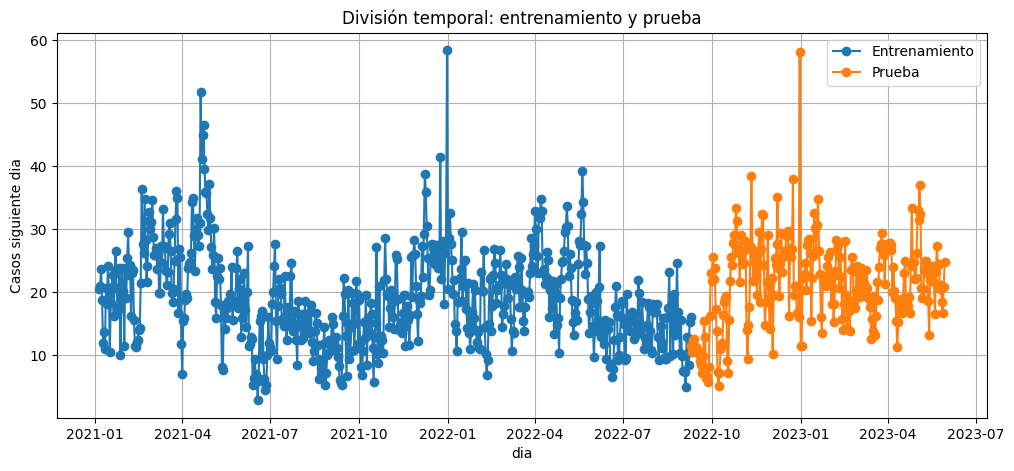

In [ ]:
plt.figure(figsize=(12, 5))

plt.plot(
    df_train["dia"],
    df_train["casos_siguiente_dia"],
    marker="o",
    label="Entrenamiento"
)

plt.plot(
    df_test["dia"],
    df_test["casos_siguiente_dia"],
    marker="o",
    label="Prueba"
)

plt.xlabel("dia")
plt.ylabel("Casos siguiente dia")
plt.title("División temporal: entrenamiento y prueba")
plt.legend()
plt.grid()

plt.show()


In [ ]:

df_modelo["riesgo_actual"] = pd.qcut(
    df_modelo["casos_diario_PM2.5"],
    q=3,
    labels=["bajo", "medio", "alto"]
)

In [ ]:

df_train = df_modelo.iloc[:n_train].copy()
df_test = df_modelo.iloc[n_train:].copy()

X_train = df_train[variables_predictoras]
y_train = df_train["riesgo_siguiente_dia"]

X_test = df_test[variables_predictoras]
y_test = df_test["riesgo_siguiente_dia"]

df_test["pred_naive"] = df_test["riesgo_actual"]

In [ ]:
acc_naive = accuracy_score(y_test, df_test["pred_naive"])

print("Accuracy modelo ingenuo:", acc_naive)

Accuracy modelo ingenuo: 0.6007604562737643


In [ ]:
modelo_arbol = DecisionTreeClassifier(
    max_depth=3,
    min_samples_leaf=5,
    random_state=42
)

modelo_arbol.fit(X_train, y_train)

pred_arbol = modelo_arbol.predict(X_test)

acc_arbol = accuracy_score(y_test, pred_arbol)

print("Accuracy árbol de decisión:", acc_arbol)

Accuracy árbol de decisión: 0.5285171102661597


In [ ]:

modelo_rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=4,
    min_samples_leaf=5,
    random_state=42
)

modelo_rf.fit(X_train, y_train)

pred_rf = modelo_rf.predict(X_test)

acc_rf = accuracy_score(y_test, pred_rf)

print("Accuracy Random Forest:", acc_rf)

Accuracy Random Forest: 0.5931558935361216


In [ ]:
df_metricas = pd.DataFrame({
    "modelo": [
        "Naive",
        "Árbol de decisión",
        "Random Forest"
    ],
    "accuracy": [
        acc_naive,
        acc_arbol,
        acc_rf
    ]
})

df_metricas

,modelo,accuracy
0,Naive,0.600760
1,Árbol de decisión,0.528517
2,Random Forest,0.593156


In [ ]:
labels = ["bajo", "medio", "alto"]

def matriz_confusion_df(y_real, y_pred, labels):
    cm = confusion_matrix(y_real, y_pred, labels=labels)

    df_cm = pd.DataFrame(
        cm,
        index=[f"Real {l}" for l in labels],
        columns=[f"Pred {l}" for l in labels]
    )

    return df_cm

In [ ]:
print("Matriz de confusión - Naive")
display(matriz_confusion_df(y_test, df_test["pred_naive"], labels))

print("Matriz de confusión - Árbol")
display(matriz_confusion_df(y_test, pred_arbol, labels))

print("Matriz de confusión - Random Forest")
display(matriz_confusion_df(y_test, pred_rf, labels))

Matriz de confusión - Naive


,Pred bajo,Pred medio,Pred alto
Real bajo,34,14,6
Real medio,17,44,31
Real alto,1,36,80


Matriz de confusión - Árbol


,Pred bajo,Pred medio,Pred alto
Real bajo,43,5,6
Real medio,36,16,40
Real alto,13,24,80


Matriz de confusión - Random Forest


,Pred bajo,Pred medio,Pred alto
Real bajo,37,10,7
Real medio,18,40,34
Real alto,7,31,79


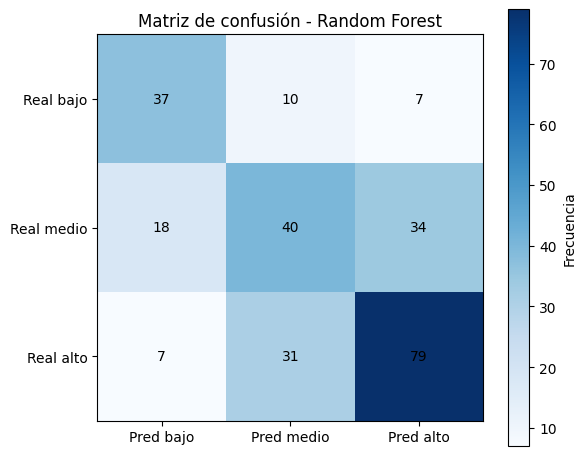

In [ ]:
df_cm_rf = matriz_confusion_df(y_test, pred_rf, labels)

plt.figure(figsize=(6, 5))

plt.imshow(df_cm_rf, cmap='Blues')

plt.xticks(range(len(labels)), [f"Pred {l}" for l in labels])
plt.yticks(range(len(labels)), [f"Real {l}" for l in labels])

plt.title("Matriz de confusión - Random Forest")
plt.colorbar(label="Frecuencia")

for i in range(len(labels)):
    for j in range(len(labels)):
        plt.text(
            j,
            i,
            df_cm_rf.iloc[i, j],
            ha="center",
            va="center"
        )

plt.tight_layout()
plt.show()

In [ ]:
print("Reporte - Árbol de decisión")
print(classification_report(y_test, pred_arbol))

print("Reporte - Random Forest")
print(classification_report(y_test, pred_rf))

Reporte - Árbol de decisión
              precision    recall  f1-score   support

        alto       0.63      0.68      0.66       117
        bajo       0.47      0.80      0.59        54
       medio       0.36      0.17      0.23        92

    accuracy                           0.53       263
   macro avg       0.49      0.55      0.49       263
weighted avg       0.50      0.53      0.50       263

Reporte - Random Forest
              precision    recall  f1-score   support

        alto       0.66      0.68      0.67       117
        bajo       0.60      0.69      0.64        54
       medio       0.49      0.43      0.46        92

    accuracy                           0.59       263
   macro avg       0.58      0.60      0.59       263
weighted avg       0.59      0.59      0.59       263



In [ ]:
importancias = pd.DataFrame({
    "variable": variables_predictoras,
    "importancia": modelo_rf.feature_importances_
})

importancias = importancias.sort_values(
    "importancia",
    ascending=False
)

importancias

,variable,importancia
0,casos_diario_PM2.5,0.256793
4,promedio_movil_3,0.189410
5,promedio_movil_5,0.177915
1,lag_1,0.102123
2,lag_2,0.101106
7,cambio_relativo,0.077122
6,cambio_diario,0.066334
3,lag_3,0.029198


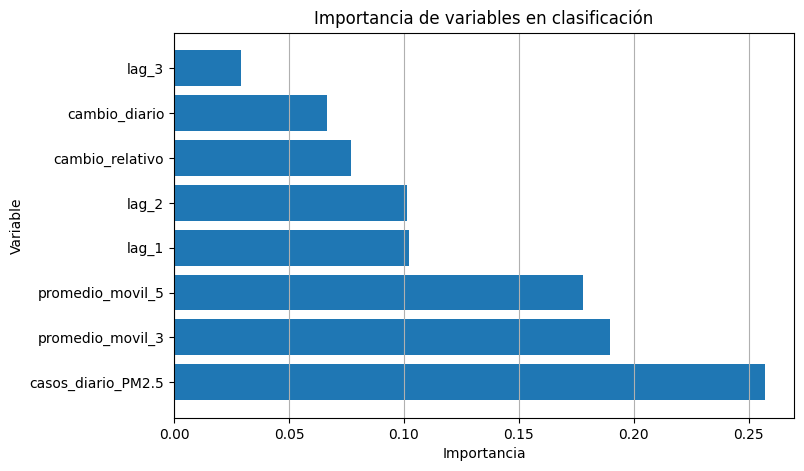

In [ ]:
plt.figure(figsize=(8, 5))

plt.barh(
    importancias["variable"],
    importancias["importancia"]
)

plt.xlabel("Importancia")
plt.ylabel("Variable")
plt.title("Importancia de variables en clasificación")
plt.grid(axis="x")

plt.show()

In [ ]:
mapa_riesgo = {
    "bajo": 0,
    "medio": 1,
    "alto": 2
}

df_test["riesgo_real_num"] = df_test["riesgo_siguiente_dia"].map(mapa_riesgo)
df_test["riesgo_rf_num"] = pd.Series(pred_rf, index=df_test.index).map(mapa_riesgo)
df_test["riesgo_naive_num"] = df_test["pred_naive"].map(mapa_riesgo)

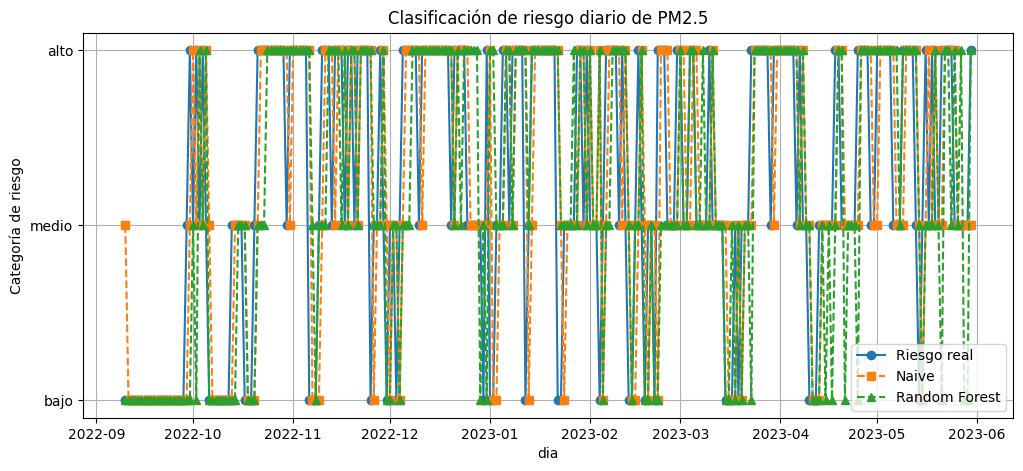

In [ ]:
plt.figure(figsize=(12, 5))

plt.plot(
    df_test["dia"],
    df_test["riesgo_real_num"],
    marker="o",
    label="Riesgo real"
)

plt.plot(
    df_test["dia"],
    df_test["riesgo_naive_num"],
    marker="s",
    linestyle="--",
    label="Naive"
)

plt.plot(
    df_test["dia"],
    df_test["riesgo_rf_num"],
    marker="^",
    linestyle="--",
    label="Random Forest"
)

plt.yticks([0, 1, 2], ["bajo", "medio", "alto"])

plt.xlabel("dia")
plt.ylabel("Categoría de riesgo")
plt.title("Clasificación de riesgo diario de PM2.5")
plt.legend()
plt.grid()

plt.show()


In [ ]:
valores_arboles = [50, 100, 200]
valores_depth = [2, 3, 4, 5, 6]
valores_leaf = [1, 3, 5, 10]

resultados = []

for n_est in valores_arboles:
    for depth in valores_depth:
        for leaf in valores_leaf:

            modelo_temp = RandomForestClassifier(
                n_estimators=n_est,
                max_depth=depth,
                min_samples_leaf=leaf,
                random_state=42
            )

            modelo_temp.fit(X_train, y_train)

            pred_temp = modelo_temp.predict(X_test)

            acc_temp = accuracy_score(y_test, pred_temp)

            resultados.append({
                "n_estimators": n_est,
                "max_depth": depth,
                "min_samples_leaf": leaf,
                "accuracy": acc_temp
            })

df_grid = pd.DataFrame(resultados)

df_grid.sort_values("accuracy", ascending=False).head(10)

,n_estimators,max_depth,min_samples_leaf,accuracy
14,50,5,5,0.615970
15,50,5,10,0.615970
13,50,5,3,0.615970
8,50,4,1,0.608365
59,200,6,10,0.608365
50,200,4,5,0.608365
51,200,4,10,0.608365
48,200,4,1,0.604563
55,200,5,10,0.604563
49,200,4,3,0.604563


In [ ]:
mejor = df_grid.sort_values("accuracy", ascending=False).iloc[0]

mejor

,14
n_estimators,50.00000
max_depth,5.00000
min_samples_leaf,5.00000
accuracy,0.61597


In [ ]:
modelo_rf_final = RandomForestClassifier(
    n_estimators=int(mejor["n_estimators"]),
    max_depth=int(mejor["max_depth"]),
    min_samples_leaf=int(mejor["min_samples_leaf"]),
    random_state=42
)

modelo_rf_final.fit(X_train, y_train)

pred_rf_final = modelo_rf_final.predict(X_test)

acc_rf_final = accuracy_score(y_test, pred_rf_final)

print("Random Forest ajustado")
print("Accuracy:", acc_rf_final)

Random Forest ajustado
Accuracy: 0.6159695817490495


In [ ]:
df_metricas_final = pd.DataFrame({
    "modelo": [
        "Naive",
        "Árbol",
        "Random Forest inicial",
        "Random Forest ajustado"
    ],
    "accuracy": [
        acc_naive,
        acc_arbol,
        acc_rf,
        acc_rf_final
    ]
})

df_metricas_final.sort_values("accuracy", ascending=False)

,modelo,accuracy
3,Random Forest ajustado,0.615970
0,Naive,0.600760
2,Random Forest inicial,0.593156
1,Árbol,0.528517


In [ ]:
df_cm_final = matriz_confusion_df(
    y_test,
    pred_rf_final,
    labels
)

df_cm_final

,Pred bajo,Pred medio,Pred alto
Real bajo,37,10,7
Real medio,15,44,33
Real alto,4,32,81


In [ ]:

print(classification_report(y_test, pred_rf_final))

              precision    recall  f1-score   support

        alto       0.67      0.69      0.68       117
        bajo       0.66      0.69      0.67        54
       medio       0.51      0.48      0.49        92

    accuracy                           0.62       263
   macro avg       0.61      0.62      0.62       263
weighted avg       0.61      0.62      0.61       263



Para este proyecto se utilizo como variable principal las particulas PM2.5 ya que es unos de los cantaminantes mas comunes en la CDMX donde es causante de enfermedades respiratorias, donde al tener la investigacion Naives se ajusto mejor ya que se adecua de mejor manera a los datos reales, para el lado de la clasificasion de igual mente Naives clasifica de mejor manera ya que alcanza un 60% de efectividad aproximadamente por lo que no pudieron mejorarlo.

Por lo que al observar las graficas el modelo si se ajusta los dias de contaminacion alto, una vez analizando este contaminate podemos concluir que al usar un solo contaminante no podemos determinar muchos factores como la causa de la fuente del contaminante, que problema podria traer, como interactua los otros contaminantes etc. por lo que es importante contar con mas infomacion de otros contaminante.